In [1]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

WEIGHTS = "/home/peeradon/lka-carla-yolo/lka_ws/src/lka_dataset_collection/scripts/runs/segment/training/runs/lka_seg_l5/weights/best.pt"
model = YOLO(WEIGHTS)

/home/peeradon/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
results = model.val(
    data="/home/peeradon/lka-carla-yolo/lka.yolo26/data.yaml",
    split="val",
    device=0,
)
print(f"mAP50-mask: {results.seg.map50:.4f}")
print(f"mAP50-95-mask: {results.seg.map:.4f}")

Ultralytics 8.4.7 🚀 Python-3.10.12 torch-2.9.1+cu128 CUDA:0 (NVIDIA GeForce RTX 5070 Ti, 15837MiB)
YOLO26l-seg summary (fused): 207 layers, 27,905,298 parameters, 0 gradients, 149.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 14787.5±2964.2 MB/s, size: 519.5 KB)
val: Scanning /home/peeradon/lka-carla-yolo/lka.yolo26/valid/labels.cache... 400 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400 119.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 8.4it/s 3.0s<0.1s
                   all        400       1571      0.984      0.994      0.995      0.944      0.883      0.867      0.885      0.705
          left_marking        400       1171       0.97      0.988      0.994      0.896      0.767      0.735      0.775       0.47
            right_edge        400        400      0.999          1      0.995      0.992          1      0.999      0.995    


image 1/1 /home/peeradon/lka-carla-yolo/lka.yolo26/valid/images/001520_jpg.rf.2x7R4t06lEZ2xyBJLmnJ.jpg: 384x640 3 left_markings, 1 right_edge, 7.3ms
Speed: 5.9ms preprocess, 7.3ms inference, 0.7ms postprocess per image at shape (1, 3, 384, 640)


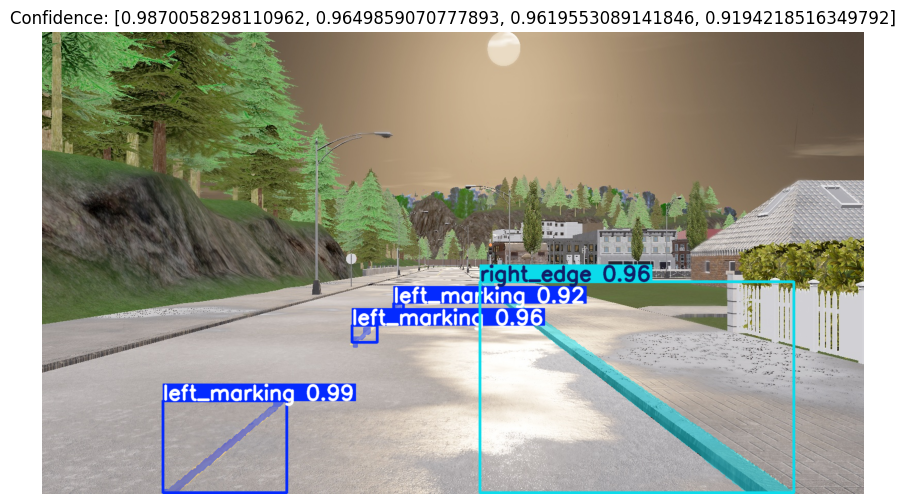

In [5]:
%matplotlib inline
import glob, random
import cv2
import matplotlib.pyplot as plt

val_imgs = glob.glob("/home/peeradon/lka-carla-yolo/lka.yolo26/valid/images/*.jpg")
img_path = random.choice(val_imgs)

result = model.predict(img_path, conf=0.25, device=0)[0]
annotated = result.plot()

plt.figure(figsize=(12, 6))
plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
plt.title(f"Confidence: {result.boxes.conf.tolist() if result.boxes else 'no boxes'}")
plt.axis("off")
plt.show()


In [6]:
import numpy as np

results = model.predict(val_imgs[:20], conf=0.25, device=0)
confs = [r.boxes.conf.mean().item() for r in results if len(r.boxes)]
print(f"Mean confidence over 20 samples: {np.mean(confs):.4f}")
print(f"Min: {np.min(confs):.4f}  Max: {np.max(confs):.4f}")


0: 384x640 2 left_markings, 1 right_edge, 4.4ms
1: 384x640 3 left_markings, 1 right_edge, 4.4ms
2: 384x640 2 left_markings, 1 right_edge, 4.4ms
3: 384x640 2 left_markings, 1 right_edge, 4.4ms
4: 384x640 2 left_markings, 1 right_edge, 4.4ms
5: 384x640 2 left_markings, 1 right_edge, 4.4ms
6: 384x640 2 left_markings, 1 right_edge, 4.4ms
7: 384x640 2 left_markings, 1 right_edge, 4.4ms
8: 384x640 2 left_markings, 1 right_edge, 4.4ms
9: 384x640 2 left_markings, 1 right_edge, 4.4ms
10: 384x640 3 left_markings, 1 right_edge, 4.4ms
11: 384x640 2 left_markings, 1 right_edge, 4.4ms
12: 384x640 3 left_markings, 1 right_edge, 4.4ms
13: 384x640 2 left_markings, 1 right_edge, 4.4ms
14: 384x640 3 left_markings, 1 right_edge, 4.4ms
15: 384x640 3 left_markings, 1 right_edge, 4.4ms
16: 384x640 2 left_markings, 1 right_edge, 4.4ms
17: 384x640 2 left_markings, 1 right_edge, 4.4ms
18: 384x640 3 left_markings, 1 right_edge, 4.4ms
19: 384x640 3 left_markings, 1 right_edge, 4.4ms
Speed: 1.2ms preprocess, 4.4m